# Phase 1: Data Exploration - La Trobe Street Bike Lanes & Parking
This notebook explores the City of Melbourne datasets to identify bike lane installation timelines and parking sensor coverage along La Trobe Street.

## Datasets
1. **Bicycle Network**: Spatial layout of bike lanes.
2. **On-street Parking Bays**: Locations of the physical parking bays and sensors.
3. **On-street Parking Sensor Data (Records)**: Time-series occupancy data.


In [1]:
import pandas as pd
import geopandas as gpd
import requests
import json

# Fetch Bicycle Network GeoJSON
bike_url = "https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/bicycle-network/exports/geojson"
print("Fetching Bicycle Network...")
gdf_bike = gpd.read_file(bike_url)
print(f"Loaded {len(gdf_bike)} bike infrastructure segments.")

# Fetch On-street Parking Bays GeoJSON
bays_url = "https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/on-street-parking-bays/exports/geojson"
print("Fetching Parking Bays...")
gdf_bays = gpd.read_file(bays_url)
print(f"Loaded {len(gdf_bays)} parking bays.")


Fetching Bicycle Network...


Loaded 130048 bike infrastructure segments.
Fetching Parking Bays...


Loaded 29053 parking bays.


In [2]:
print("--- Bicycle Network Columns ---")
print(gdf_bike.columns)
print(gdf_bike.head(2))

print("\n--- Parking Bays Columns ---")
print(gdf_bays.columns)
print(gdf_bays.head(2))


--- Bicycle Network Columns ---
Index(['geo_point_2d', 'objectid', 'roadclass', 'width', 'oneway',
       'management', 'direction', 'shape_length', 'description', 'geometry'],
      dtype='str')
                                       geo_point_2d objectid roadclass width  \
0  {'lon': 144.92878443145, 'lat': -37.79213546455}    20011         5     0   
1    {'lon': 144.9277126669, 'lat': -37.7935783457}    20019         5     0   

  oneway     management direction  shape_length description  \
0    NaN  Council Major         B      5.772598  Local Road   
1    NaN  Council Major         B      5.145527  Local Road   

                                            geometry  
0  LINESTRING (144.92878 -37.79211, 144.92879 -37...  
1  LINESTRING (144.92771 -37.79356, 144.92771 -37...  

--- Parking Bays Columns ---
Index(['roadsegmentid', 'kerbsideid', 'roadsegmentdescription', 'latitude',
       'longitude', 'lastupdated', 'geometry'],
      dtype='str')
   roadsegmentid kerbsideid  \
0   

In [3]:
# Filter Bicycle Network for La Trobe
bike_latrobe = gdf_bike[gdf_bike.apply(lambda row: row.astype(str).str.contains('La Trobe', case=False).any(), axis=1)]
print(f"Found {len(bike_latrobe)} bike network segments for La Trobe Street.")

# Filter Parking Bays for La Trobe
st_cols = [c for c in gdf_bays.columns if 'street' in c.lower() or 'st_' in c.lower()]
print("Street columns in Bays:", st_cols)

if st_cols:
    bays_latrobe = gdf_bays[gdf_bays[st_cols[0]].str.contains('La Trobe', case=False, na=False)]
    print(f"Found {len(bays_latrobe)} parking bays on La Trobe Street.")
else:
    bays_latrobe = gdf_bays[gdf_bays.apply(lambda row: row.astype(str).str.contains('La Trobe', case=False).any(), axis=1)]
    print(f"Found {len(bays_latrobe)} parking bays on La Trobe Street (broad search).")

print("\nSample La Trobe Parking Bays:")
print(bays_latrobe.head(2))


Found 0 bike network segments for La Trobe Street.
Street columns in Bays: []


Found 480 parking bays on La Trobe Street (broad search).

Sample La Trobe Parking Bays:
      roadsegmentid kerbsideid  \
3             21618        NaN   
2065          21505        NaN   

                                 roadsegmentdescription   latitude  \
3     Swanston Street between La Trobe Street and Li... -37.809238   
2065  La Trobe Street between Adderley Street and Sp... -37.813440   

       longitude lastupdated                     geometry  
3     144.963572  2025-06-03  POINT (144.96357 -37.80924)  
2065  144.950724  2025-06-03  POINT (144.95072 -37.81344)  


Matched 1891 bike network segments running along La Trobe St parking bays.
                                          geo_point_2d objectid roadclass  \
344  {'lon': 144.96591662650002, 'lat': -37.8080667...    22970         4   
551  {'lon': 144.9541151208, 'lat': -37.81352068005...    24729         5   
594   {'lon': 144.95907596995, 'lat': -37.81143864795}    25032         4   
655      {'lon': 144.9534734887, 'lat': -37.811509844}    25595         2   
659    {'lon': 144.96109411875, 'lat': -37.8097442518}    25631         3   

    width oneway     management direction  shape_length        description  \
344     0    NaN  Council Major         B     34.421212     Collector Road   
551     0     FT  Council Major         F     18.150113         Local Road   
594     0    NaN  Council Major         B     14.485404     Collector Road   
655     0    NaN       Arterial         B      5.938692     Arterial  Road   
659     0    NaN  Council Major         B      5.110701  Sub-Arterial Ro

/var/folders/lq/wcc6q9v15d93q55hnqbd8qcc00wxg3/T/ipykernel_1925/2463888719.py:8: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  buffer_union = bays_buffer.unary_union


Matplotlib is building the font cache; this may take a moment.


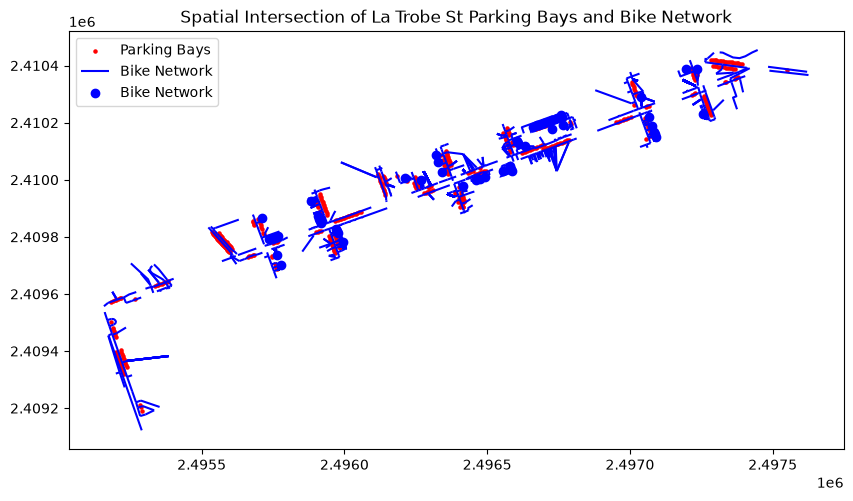

In [4]:
# Buffer the La Trobe parking bays by 20 meters to capture the adjacent road/bike corridor
# Since points are in EPSG:4326, we should project to a metric CRS (e.g., EPSG:7899 / VICGRID) before buffering
bays_latrobe_proj = bays_latrobe.to_crs(epsg=7899)
bays_buffer = bays_latrobe_proj.geometry.buffer(20) # 20 meters

# Project bike network and dissolve buffer for faster intersection
gdf_bike_proj = gdf_bike.to_crs(epsg=7899)
buffer_union = bays_buffer.unary_union

# Intersect
bike_latrobe_matched = gdf_bike_proj[gdf_bike_proj.geometry.intersects(buffer_union)]
print(f"Matched {len(bike_latrobe_matched)} bike network segments running along La Trobe St parking bays.")

# Print some matches
print(bike_latrobe_matched.head(5))

# Plot to verify
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
bays_latrobe_proj.plot(ax=ax, color='red', label='Parking Bays', markersize=5)
bike_latrobe_matched.plot(ax=ax, color='blue', label='Bike Network')
plt.title("Spatial Intersection of La Trobe St Parking Bays and Bike Network")
plt.legend()
plt.show()
